In [88]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from scipy.stats import dirichlet, beta


# Equilateral triangle vertices in 2D
vertices = np.array([
    [0.5, np.sqrt(3)/2],  # State 1 (top)
    [0.0, 0.0],           # State 2 (bottom-left)
    [1.0, 0.0],           # State 3 (bottom-right)
])

def bary_to_cart(bary, vertices):
    return bary @ vertices

# Generate a fine grid of barycentric coordinates on the simplex
n = 100
bary_coords = []
for i in range(n + 1):
    for j in range(n + 1 - i):
        k = n - i - j
        b = np.array([i, j, k]) / n
        b = np.clip(b, 1e-6, 1.0)
        b /= b.sum()
        bary_coords.append(b)

bary_coords = np.array(bary_coords)
cart_coords = bary_to_cart(bary_coords, vertices)
triang = mtri.Triangulation(cart_coords[:, 0], cart_coords[:, 1])



In [89]:
def gdd_pdf_k3(bary, beta1, gamma1, beta2, gamma2):
    """
    Generalized Dirichlet PDF for K=3.
    
    Parameters:
    -----------
    bary : ndarray of shape (N, 3)
        Barycentric coordinates [x1, x2, x3] where x1+x2+x3=1
    beta1, gamma1, beta2, gamma2 : float
        GDD shape parameters
    
    Returns:
    --------
    pdf : ndarray of shape (N,)
        PDF values
    """
    x1 = bary[:, 0]
    x2 = bary[:, 1]
    x3 = bary[:, 2]
    
    # Avoid numerical issues at boundaries
    x1 = np.clip(x1, 1e-8, 1.0)
    x2 = np.clip(x2, 1e-8, 1.0)
    x3 = np.clip(x3, 1e-8, 1.0)
    
    B1 = beta_function(beta1, gamma1)
    B2 = beta_function(beta2, gamma2)
    
    pdf = (1.0 / (B1 * B2) * 
           x1**(beta1 - 1) * 
           (x2 + x3)**(gamma1 - 1) * 
           x2**(beta2 - 1) * 
           x3**(gamma2 - 1))
    
    return pdf


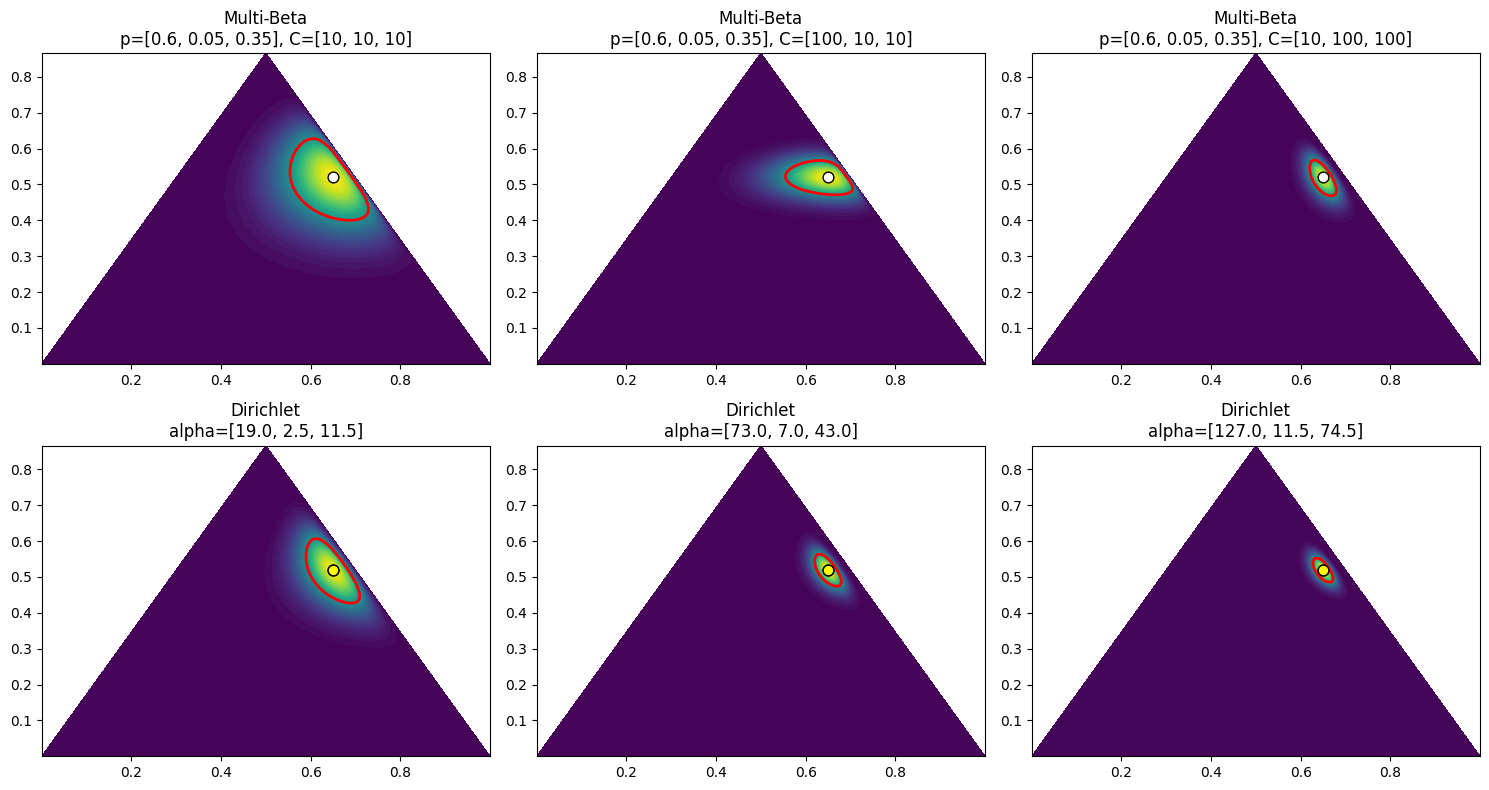

In [90]:
p = np.array([0.6, 0.05, 0.35])
C_1 = np.array([10, 10, 10])
C_2 = np.array([100, 10, 10])
C_3 = np.array([10, 100, 100])
alpha_1 = p * np.sum(C_1) + 1
alpha_2 = p * np.sum(C_2) + 1
alpha_3 = p * np.sum(C_3) + 1

def multi_beta_pdf(bary, p, C):
    pdf = np.ones(bary.shape[0])
    for i, (p_val, C_val) in enumerate(zip(p, C)):
        a = p_val * C_val
        b = (1 - p_val) * C_val
        beta_pdf = beta.pdf(bary[:, i], a+1, b+1)
        pdf = pdf * beta_pdf
    return pdf

def plot_contours(pdf, triang, p, title='Combined PDF from Beta Distributions'):
    plt.figure(figsize=(6, 5))
    ax = plt.gca()
    ax.tricontourf(triang, pdf, levels=50, cmap='viridis')
    ax.tricontour(triang, pdf, levels=[0.5 * pdf.max()], colors='red', linewidths=2)
    p_arr = np.asarray(p, dtype=float)
    p_arr = p_arr / p_arr.sum()  # ensure valid barycentric coords

    p_xy = bary_to_cart(p_arr.reshape(1, 3), vertices)[0]
    ax.scatter(p_xy[0], p_xy[1], color='white', edgecolor='black', s=80, zorder=5)
    ax.text(p_xy[0] + 0.015, p_xy[1] + 0.015, f"p={p}", color='white', fontsize=9, zorder=6)

    ax.set_title(title)
    plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Top row: product of Beta PDFs (multi_beta_pdf) for C_1, C_2, C_3
for idx, C in enumerate([C_1, C_2, C_3]):
    pdf_vals = multi_beta_pdf(bary_coords, p, C)
    ax = axes[0, idx]
    ax.tricontourf(triang, pdf_vals, levels=50, cmap='viridis')
    ax.tricontour(triang, pdf_vals, levels=[0.5 * pdf_vals.max()], colors='red', linewidths=2)
    p_arr = p / p.sum()
    p_xy = bary_to_cart(p_arr.reshape(1, 3), vertices)[0]
    ax.scatter(p_xy[0], p_xy[1], color='white', edgecolor='black', s=60, zorder=5)
    ax.set_title(f"Multi-Beta\np={p.tolist()}, C={C.tolist()}")

# Bottom row: Dirichlet PDFs for alpha_1, alpha_2, alpha_3
for idx, alpha in enumerate([alpha_1, alpha_2, alpha_3]):
    dir_pdf_vals = dirichlet.pdf(bary_coords.T, alpha)
    ax = axes[1, idx]
    ax.tricontourf(triang, dir_pdf_vals, levels=50, cmap='viridis')
    ax.tricontour(triang, dir_pdf_vals, levels=[0.5 * dir_pdf_vals.max()], colors='red', linewidths=2)
    p_arr = p / p.sum()
    p_xy = bary_to_cart(p_arr.reshape(1, 3), vertices)[0]
    evidence = alpha - 1
    E_alpha = evidence / evidence.sum()
    E_xy = bary_to_cart(E_alpha.reshape(1, 3), vertices)[0]
    ax.scatter(p_xy[0], p_xy[1], color='white', edgecolor='black', s=60, zorder=5)
    ax.scatter(E_xy[0], E_xy[1], color='yellow', edgecolor='black', s=60, zorder=5)
    ax.set_title(f"Dirichlet\nalpha={alpha.tolist()}")

plt.tight_layout()
plt.show()


In [91]:
import numpy as np
from scipy.special import digamma, polygamma

def inv_digamma(y, n_newton=5):
    # Minka's initializer: accurate to ~1e-2, Newton converges quadratically
    x = np.where(y >= -2.22, np.exp(y) + 0.5, -1.0 / (y - digamma(1)))
    for _ in range(n_newton):
        x = x - (digamma(x) - y) / polygamma(1, x)
    return x

def solve_alpha_fp(X, tol=1e-3, max_iter=600):
    X = np.asarray(X, dtype=np.float64)
    X = np.log(X)
    assert np.all(X < 0), "need X[k] < 0 for a solution to exist"

    # init from the marginal: ignore ψ(Σα) term on first pass
    alpha = inv_digamma(X + digamma(2))

    for _ in range(max_iter):
        s = digamma(alpha.sum())
        new_alpha = inv_digamma(X + s)
        if np.max(np.abs(new_alpha - alpha)) < tol:
            alpha = new_alpha
            break
        alpha = new_alpha

    print(f"converged in {_} iterations")
    return alpha, alpha / alpha.sum()


converged in 13 iterations
converged in 20 iterations
converged in 57 iterations
converged in 567 iterations
converged in 20 iterations
converged in 57 iterations
converged in 52 iterations
converged in 599 iterations
converged in 585 iterations


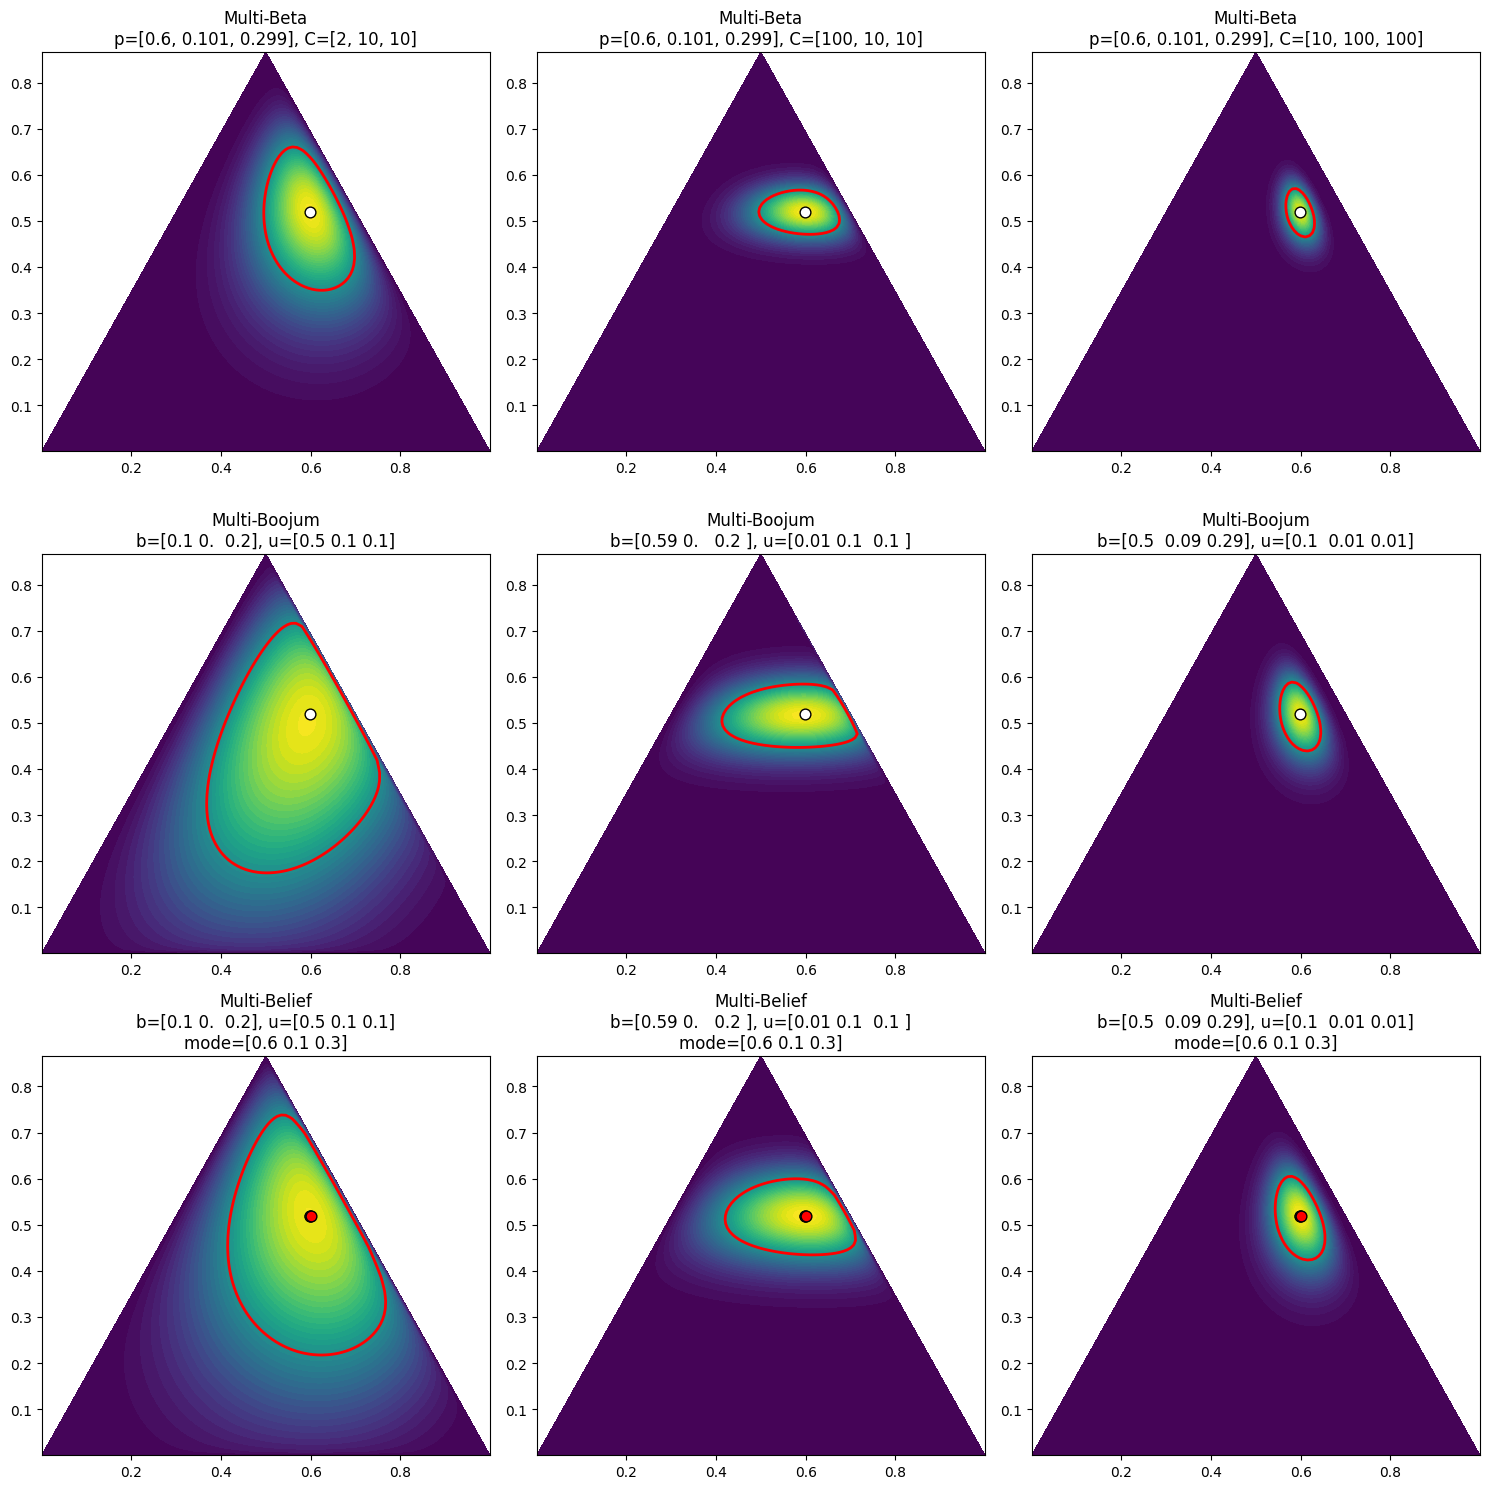

In [92]:
p = np.array([0.6, 0.101, 0.299])
C_1 = np.array([2, 10, 10])
C_2 = np.array([100, 10, 10])
C_3 = np.array([10, 100, 100])

u_1 = 1/C_1
u_2 = 1/C_2
u_3 = 1/C_3

b_1 = p - u_1
b_2 = p - u_2
b_3 = p - u_3

def boojum_alpha_from_b_and_u(b, u):
    alphas = []
    for b_val, u_val in zip(b, u):
        alphas.append(solve_alpha_fp([b_val, 1 - b_val - u_val])[0])
    return np.array(alphas)

def multi_beta_from_alphas(bary, alpha):
    pdf = np.ones(bary.shape[0])
    for i, alpha_vals in enumerate(alpha):
        a = alpha_vals[0]
        b = alpha_vals[1]
        
        beta_pdf = beta.pdf(bary[:, i], a + 1, b + 1)
        pdf = pdf * beta_pdf
    return pdf

def belief_alpha_from_b_and_u(b, u, a, W=0.5):
    alphas = []
    b_tot = b.sum()
    u_tot = u.sum()
    W = 1 / b.shape[0]
    for i, (b_val, u_val) in enumerate(zip(b, u)):
        alpha_1 = W*((b_val+u_val)/u_val )
        alpha_2 = W*((1 - b_val - u_val)/u_val)
        alphas.append([alpha_1, alpha_2])

    return np.array(alphas)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# Top row: product of Beta PDFs (multi_beta_pdf) for C_1, C_2, C_3
for idx, C in enumerate([C_1, C_2, C_3]):
    pdf_vals = multi_beta_pdf(bary_coords, p, C)
    ax = axes[0, idx]
    ax.tricontourf(triang, pdf_vals, levels=50, cmap='viridis')
    ax.tricontour(triang, pdf_vals, levels=[0.5 * pdf_vals.max()], colors='red', linewidths=2)
    p_arr = p / p.sum()
    p_xy = bary_to_cart(p_arr.reshape(1, 3), vertices)[0]
    ax.scatter(p_xy[0], p_xy[1], color='white', edgecolor='black', s=60, zorder=5)
    ax.set_title(f"Multi-Beta\np={p.tolist()}, C={C.tolist()}")

# Bottom row: Dirichlet PDFs for alpha_1, alpha_2, alpha_3
for idx, C in enumerate([C_1, C_2, C_3]):
    u = 1 / C
    b = p - u
    alpha = boojum_alpha_from_b_and_u(b, u)

    dir_pdf_vals = multi_beta_from_alphas(bary_coords, alpha)
    ax = axes[1, idx]
    ax.tricontourf(triang, dir_pdf_vals, levels=50, cmap='viridis')
    ax.tricontour(triang, dir_pdf_vals, levels=[0.5 * dir_pdf_vals.max()], colors='red', linewidths=2)
    p_arr = p / p.sum()
    p_xy = bary_to_cart(p_arr.reshape(1, 3), vertices)[0]
    ax.scatter(p_xy[0], p_xy[1], color='white', edgecolor='black', s=60, zorder=5)
    ax.set_title(f"Multi-Boojum\nb={np.round(b.tolist(), 2)}, u={np.round(u.tolist(), 2)}")

# Bottom row: Dirichlet PDFs for alpha_1, alpha_2, alpha_3
for idx, C in enumerate([C_1, C_2, C_3]):
    u = 1 / C
    b = p - u
    prior = np.array([1/3, 1/3, 1/3])
    alpha = belief_alpha_from_b_and_u(b, u, a=prior, W=0.5)
    p_hat = b + u

    dir_pdf_vals = multi_beta_from_alphas(bary_coords, alpha)
    ax = axes[2, idx]
    ax.tricontourf(triang, dir_pdf_vals, levels=50, cmap='viridis')
    ax.tricontour(triang, dir_pdf_vals, levels=[0.5 * dir_pdf_vals.max()], colors='red', linewidths=2)
    p_arr = p / p.sum()
    p_hat_arr = p_hat / p_hat.sum()
    p_mode_arr = bary_coords[np.argmax(dir_pdf_vals)]
    p_xy = bary_to_cart(p_arr.reshape(1, 3), vertices)[0]
    p_hat_xy = bary_to_cart(p_hat_arr.reshape(1, 3), vertices)[0]
    p_mode_xy = bary_to_cart(p_mode_arr.reshape(1, 3), vertices)[0]
    ax.scatter(p_xy[0], p_xy[1], color='white', edgecolor='black', s=60, zorder=5)
    ax.scatter(p_hat_xy[0], p_hat_xy[1], color='yellow', edgecolor='black', s=60, zorder=5)
    ax.scatter(p_mode_xy[0], p_mode_xy[1], color='red', edgecolor='black', s=60, zorder=5)
    ax.set_title(f"Multi-Belief\nb={np.round(b.tolist(), 2)}, u={np.round(u.tolist(), 2)}\nmode={np.round(p_mode_arr.tolist(), 2)}")

plt.tight_layout()
plt.show()

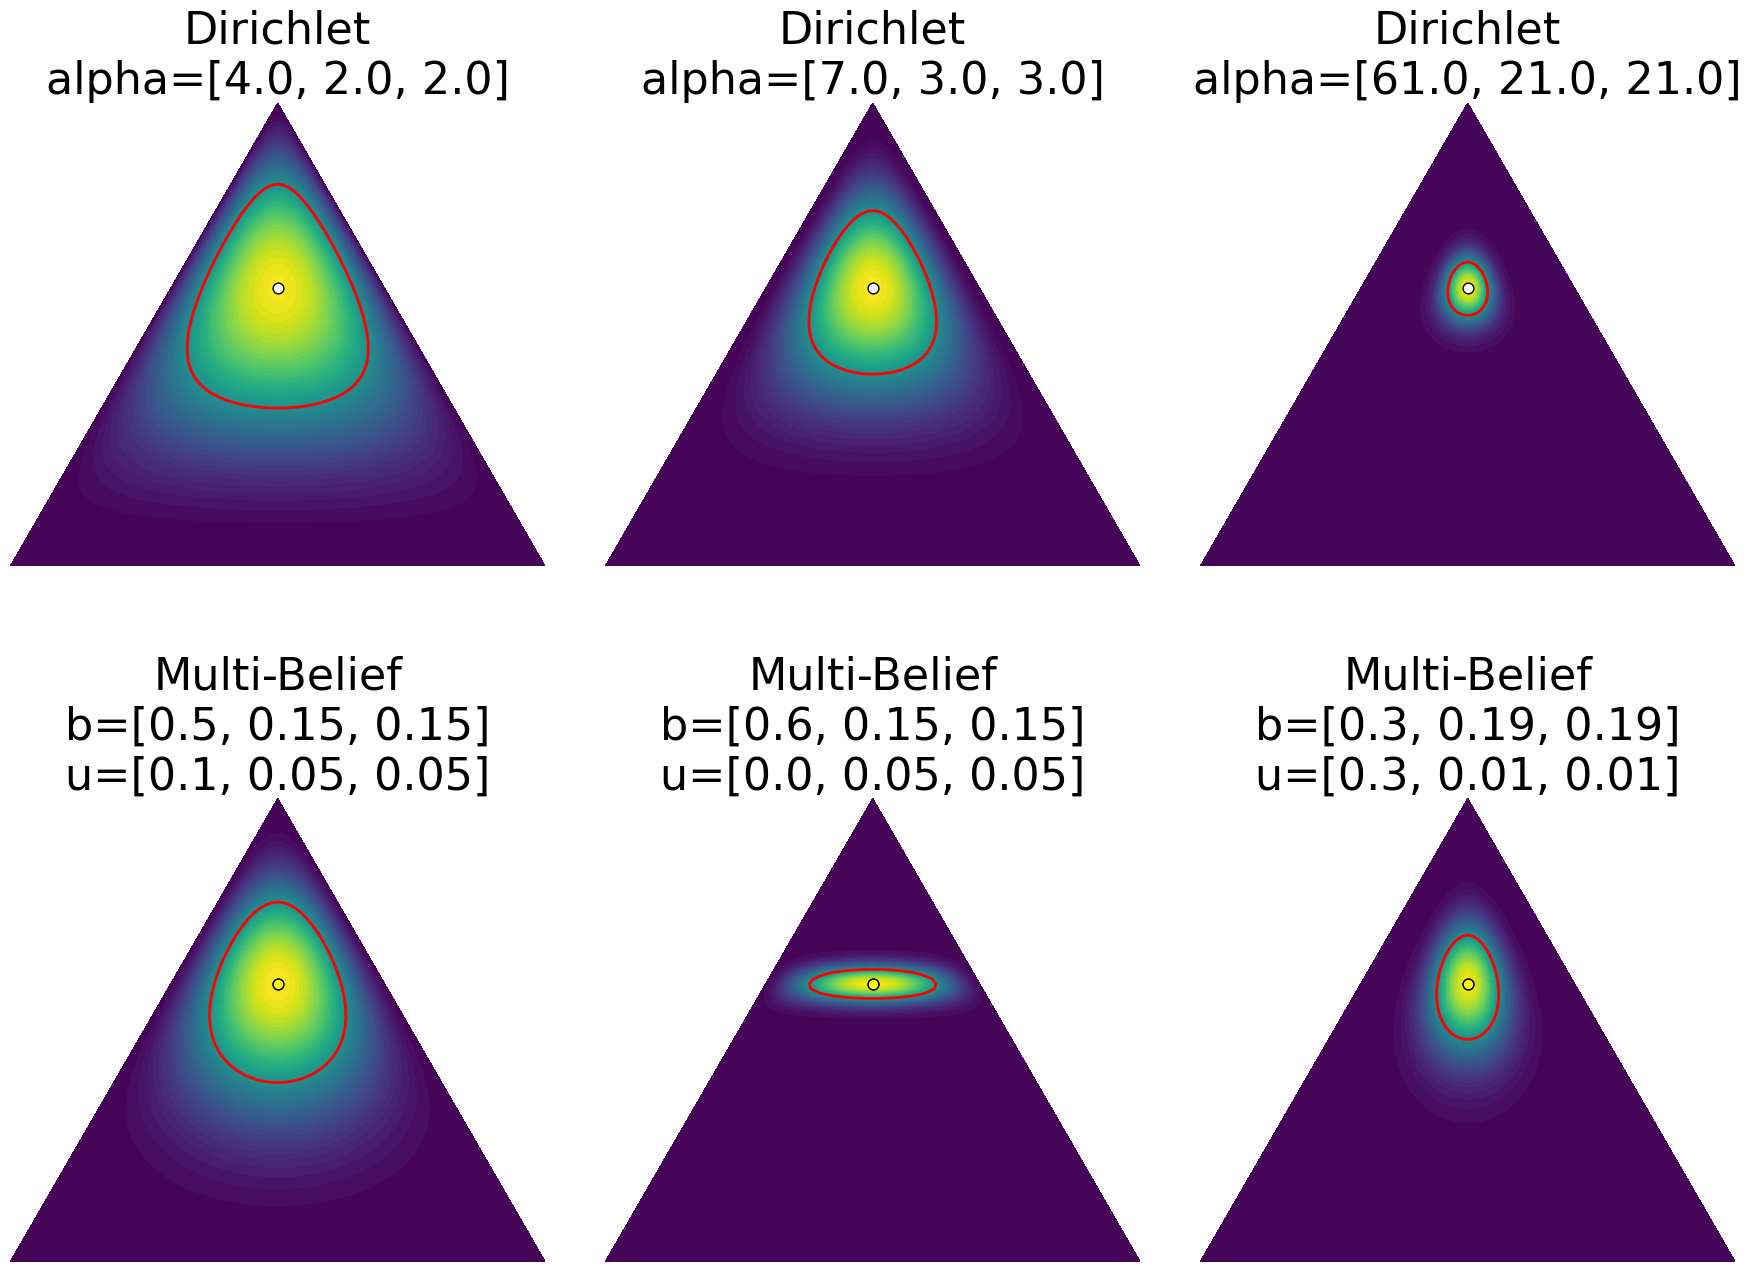

In [110]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

dirichlet_alphas = [
    np.array([0.6, 0.2, 0.2])*5 + np.ones(3),
    np.array([0.6, 0.2, 0.2])*10 + np.ones(3),
    np.array([0.6, 0.2, 0.2])*100 + np.ones(3),
]

belief_params = [
    (np.array([0.5, 0.15, 0.15]), np.array([0.1, 0.05, 0.05])),
    (np.array([0.599, 0.15, 0.15]), np.array([0.001, 0.05, 0.05])),
    (np.array([0.3, 0.19, 0.19]), np.array([0.3, 0.01, 0.01])),
]

# Top row: Dirichlet
for idx, alpha_vals in enumerate(dirichlet_alphas):
    dir_pdf_vals = dirichlet.pdf(bary_coords.T, alpha_vals)
    ax = axes[0, idx]
    ax.tricontourf(triang, dir_pdf_vals, levels=50, cmap='viridis')
    ax.tricontour(triang, dir_pdf_vals, levels=[0.5 * dir_pdf_vals.max()], colors='red', linewidths=2)
    mode = (alpha_vals - 1) / (alpha_vals.sum() - len(alpha_vals))
    mode_xy = bary_to_cart(mode.reshape(1, 3), vertices)[0]
    ax.scatter(mode_xy[0], mode_xy[1], color='white', edgecolor='black', s=60, zorder=5)
    ax.set_title(f"Dirichlet\nalpha={alpha_vals.tolist()}")
    ax.set_aspect('equal')
    ax.axis('off')

# Bottom row: Multi-Belief
for idx, (b_val, u_val) in enumerate(belief_params):
    a_prior = np.array([1/3, 1/3, 1/3])
    W = 1 / len(b_val)
    alpha_vals = np.array([
        [W * ((b_val[i] + u_val[i]) / u_val[i]), W * ((1 - b_val[i] - u_val[i]) / u_val[i])]
        for i in range(len(b_val))
    ])
    pdf_vals = multi_beta_from_alphas(bary_coords, alpha_vals)
    ax = axes[1, idx]
    ax.tricontourf(triang, pdf_vals, levels=50, cmap='viridis')
    ax.tricontour(triang, pdf_vals, levels=[0.5 * pdf_vals.max()], colors='red', linewidths=2)
    p_mode = bary_coords[np.argmax(pdf_vals)]
    p_mode_xy = bary_to_cart(p_mode.reshape(1, 3), vertices)[0]
    p_mean = b_val + u_val
    p_mean_xy = bary_to_cart((p_mean / p_mean.sum()).reshape(1, 3), vertices)[0]
    ax.scatter(p_mode_xy[0], p_mode_xy[1], color='red', edgecolor='black', s=60, zorder=5)
    ax.scatter(p_mean_xy[0], p_mean_xy[1], color='yellow', edgecolor='black', s=60, zorder=5)
    ax.set_title(f"Multi-Belief\nb={np.round(b_val, 2).tolist()}\nu={np.round(u_val, 2).tolist()}")
    ax.set_aspect('equal')
    ax.axis('off')

plt.tight_layout()
for ax in axes.ravel():
    ax.title.set_fontsize(32)

fig.subplots_adjust(hspace=0.5)
plt.show()

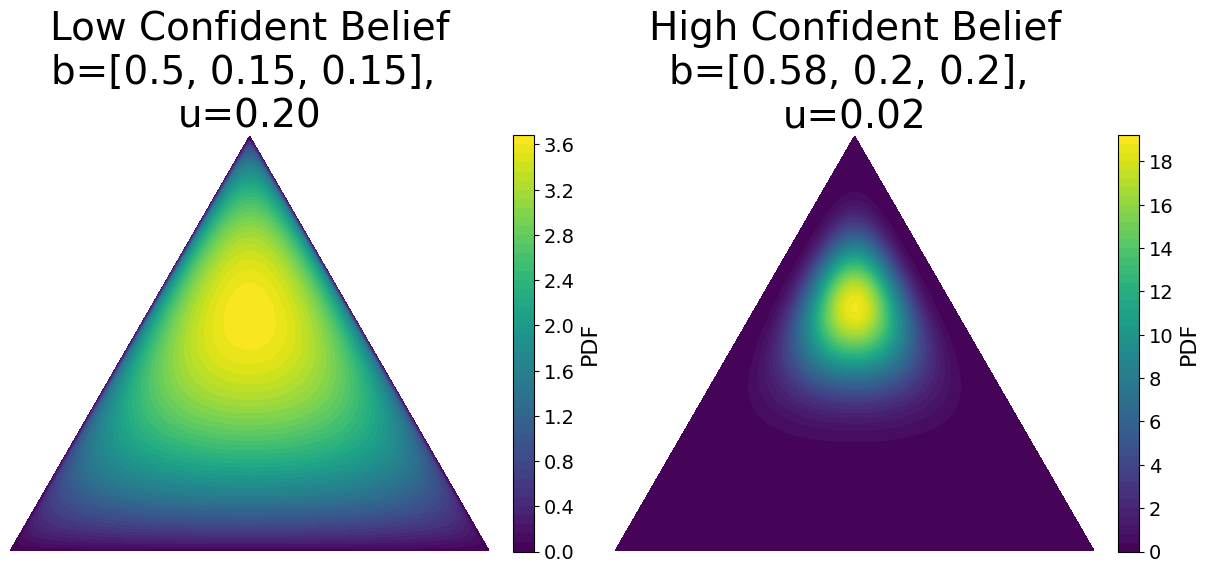

In [93]:
b_1 = np.array([0.5, 0.15, 0.15])
u_1 = 1- np.sum(b_1)

b_2 = np.array([0.58, 0.2, 0.2])
u_2 = 1- np.sum(b_2)

a = np.array([1/3, 1/3, 1/3])

alpha_1 = (1/3) * (b_1/u_1 + a) + 1
alpha_2 = (1/3) * (b_2/u_2 + a) + 1

alphas = [alpha_1, alpha_2]
titles = [
    f"Low Confident Belief\nb={b_1.tolist()}, \nu={u_1:.2f}",
    f"High Confident Belief\nb={b_2.tolist()}, \nu={u_2:.2f}",
]

fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

for ax, alpha_vals, title in zip(axes, alphas, titles):
    alpha_vals = np.asarray(alpha_vals, dtype=float)
    dir_pdf_vals = dirichlet.pdf(bary_coords.T, alpha_vals)

    contour = ax.tricontourf(triang, dir_pdf_vals, levels=50, cmap="viridis")
    ax.set_title(title, fontsize=28)
    ax.set_aspect("equal")
    ax.axis("off")
    cb = fig.colorbar(contour, ax=ax, shrink=0.8, label="PDF")
    cb.set_label("PDF", fontsize=16)
    cb.ax.tick_params(labelsize=14)

plt.show()

In [94]:
np.log(dir_pdf_vals + 1e-10)

array([-23.02585093, -23.02585093, -23.02585093, ..., -23.02585093,
       -23.02585093, -23.02585093])